In [1]:
import pandas as pd
import numpy as np
import hashlib
from collections import Counter
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Load incident data

In [2]:
df_incident = pd.read_csv('Data/fair-drg-1066-incidence-database-43456-3229/incidence_db_00002.csv')

In [3]:
df_incident = df_incident[['householdid', 'particid', 'f_date', 'death_date', 'f_mci', 'gender', 'centreid']]
df_incident

,householdid,particid,f_date,death_date,f_mci,gender,centreid
0,1.0,1,NaN,2005-08-10,NaN,1.0,1
1,NaN,2,2007-12-05,NaN,0.0,2.0,1
2,2.0,1,2007-12-12,NaN,1.0,1.0,1
3,3.0,1,NaN,NaN,NaN,1.0,1
4,NaN,2,NaN,2005-02-25,NaN,2.0,1
...,...,...,...,...,...,...,...
12860,NaN,2,2013-11-20,NaN,0.0,1.0,20
12861,10267.0,1,NaN,2012-11-15,NaN,1.0,20
12862,10268.0,1,2012-05-15,NaN,0.0,1.0,20
12863,10269.0,1,NaN,NaN,NaN,1.0,20


In [4]:
df_incident.death_date.isna().sum()

11095

In [5]:
# Replacement dictionary
centreid_dict = {
  1: "Cuba",
  2: "DR",
  3: "Peru (urban)",
  4: "Peru (rural)",
  5: "Venezuela",
  6: "Mexico (urban)",
  7: "Mexico (rural)",
  8: "Argentina (urban)",
  9: "Argentina (urban)",
  10: "China (urban)",
  11: "China (rural)",
  12: "India (urban)",
  13: "India (rural)",
  20: "Puerto Rico",
  21: "Nigeria"
}

# Apply mapping
df_incident['Countries'] = df_incident['centreid'].map(centreid_dict)

In [6]:
Counter(df_incident['centreid'])

Counter({1: 2944,
         2: 2011,
         3: 1381,
         5: 1965,
         7: 1000,
         20: 2009,
         4: 552,
         6: 1003})

# Load BBAG data

In [8]:
results_GB_orig = pd.read_parquet('Results/all-vars_all-subjects_onlyCN.parquet')

In [9]:
results_GB_orig.anydem.value_counts()

anydem
0.0    11461
Name: count, dtype: int64

## Matching

In [9]:
#results_GB_orig = pd.read_excel('Results/results_GB_extravars.xlsx')

In [10]:
import numpy as np
import hashlib

def make_generic_id(row):
  h = row['householdid']
  p = row['particid']
  def to_str(val):
    if pd.isna(val): return ""
    if isinstance(val, float) and val.is_integer(): return str(int(val))
    return str(val)
  if pd.isna(h) or pd.isna(p): return np.nan
  uid_str = to_str(h) + "_" + to_str(p)
  return 'SUBJ_' + hashlib.md5(uid_str.encode()).hexdigest()[:8]

df_incident['generic_id'] = df_incident.apply(make_generic_id, axis=1)

In [11]:
df_incident[["householdid", "particid", "generic_id"]]

In [12]:
results_GB_orig[["generic_id"]]

In [13]:
# (optional) see how many valid IDs you have
print(df_incident["generic_id"].notna().mean(), results_GB_orig["generic_id"].notna().mean())

# drop original ids to anonymize
df_incident = df_incident.drop(columns=['householdid', 'particid'])

# matching
matched = df_incident.merge(results_GB_orig, on="generic_id", how="inner", suffixes=("_inc", "_gb"))

# Define death and end date, and event


## I dont consider alive participant without f_date anda death_date

### All subjects (Here it is only controls)

In [14]:
matched = df_incident.merge(results_GB_orig, on="uid", how="inner", suffixes=("_inc", "_gb"))

matched["date"] = pd.to_datetime(matched["date"], errors="coerce")
matched["death_date"] = pd.to_datetime(matched["death_date"], errors="coerce")
matched["f_date"] = pd.to_datetime(matched["f_date"], errors="coerce")


matched["event"] = matched["death_date"].notna().astype(int)

# End date:
# - if died -> death_date
# - if not died -> f_date (last evaluation)
matched["end_date"] = matched["death_date"].fillna(matched["f_date"])

# (Optional, in case any end_date is empty)
matched["end_date"] = matched["end_date"].fillna(matched["date"].max())

# Time in years
matched["time_years"] = (matched["end_date"] - matched["date"]).dt.days / 365.25

# (Optional) mark invalid times as NaN
matched.loc[matched["time_years"] < 0, "time_years"] = np.nan
matched.loc[matched["time_years"] > 5.5, "time_years"] = np.nan

<Axes: >

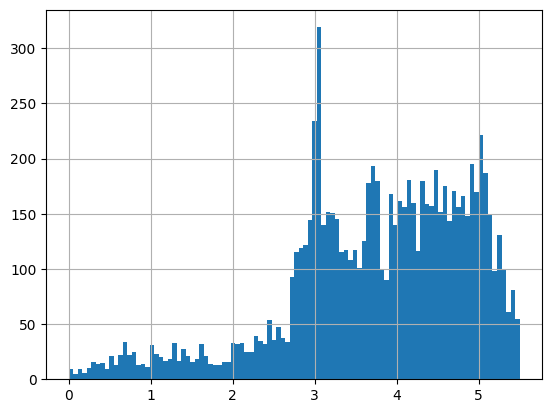

In [15]:
matched["time_years"].hist(bins = 100)

In [16]:
#a = matched[["date", "death_date", "f_date","end_date", "event"]].dropna(subset = ["f_date"])#['event']#.value_counts()

In [17]:
#a[a.event == 1]

In [16]:
import matplotlib.pyplot as plt
def forest_plot_gap(cph_unadj, cph_adj,
          color_unadj="#2196F3", color_adj="#E53935",
          gap_var="GAP_z", save_path=None):

  def extract_gap(cph):
    out = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
    out.columns = ["HR", "CI_low", "CI_high", "p_value"]
    return out.loc[gap_var]

  row_u = extract_gap(cph_unadj)
  row_a = extract_gap(cph_adj)

  models   = ["Unadjusted", "Adjusted"]
  rows    = [row_u, row_a]
  colors   = [color_unadj, color_adj]
  markers   = ["s", "o"]     # <-- square / circle
  y_positions = [1, 0]

  fig, ax = plt.subplots(figsize=(6, 2.5))

  for model, row, color, marker, y in zip(models, rows, colors, markers, y_positions):
    ax.plot([row["CI_low"], row["CI_high"]], [y, y],
        color=color, linewidth=2.0, zorder=2)
    ax.plot(row["HR"], y, marker=marker, color=color,
        ms=9, zorder=3, linestyle="None")

    p = row["p_value"]
    p_str = "p<0.001" if p < 0.001 else f"p={p:.3f}"
    ax.text(row["CI_high"] + 0.01, y,
        f"HR={row['HR']:.3f} [{row['CI_low']:.3f}–{row['CI_high']:.3f}] {p_str}",
        va="center", fontsize=8, color=color)

  ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8, zorder=1)
  ax.set_yticks(y_positions)
  ax.set_yticklabels(models, fontsize=9)
  ax.set_xlabel("Hazard Ratio (95% CI)", fontsize=9)
  ax.set_title(f"Forest Plot — {gap_var}", fontsize=10, fontweight="bold")
  ax.set_ylim(-0.5, 1.5)
  ax.set_xlim(0.95, 1.7)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  plt.tight_layout()

  if save_path:
    plt.savefig(save_path, format="pdf", bbox_inches="tight", dpi=300)
    print(f" Saved: {save_path}")

  plt.show()

#### Cox model

In [17]:
from lifelines import CoxPHFitter


df_surv = matched[['time_years', 'event', 'GAP_corrected']].dropna()

cph = CoxPHFitter().fit(df_surv, duration_col='time_years', event_col='event')

out = cph.summary.loc[['GAP_corrected'], ['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
out = out.rename(columns={
  'exp(coef)': 'HR',
  'exp(coef) lower 95%': 'CI95_low',
  'exp(coef) upper 95%': 'CI95_high',
  'p': 'p_value'
})
out


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_corrected,1.110387,1.088113,1.133118,4.167661e-24


In [18]:
covars = ['Age', 'Male', 'Education']


In [19]:
from lifelines import CoxPHFitter

def compact_all(cph):
  out = cph.summary.loc[:, ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
  out.columns = ["HR", "CI95_low", "CI95_high", "p_value"]
  return out.sort_values("p_value")




In [20]:
from lifelines import CoxPHFitter

matched["Male"] = (matched["Sex_1F_2M"] == 2).astype(int)



matched["GAP_z"] = (matched["GAP_corrected"] - matched["GAP_corrected"].mean()) / matched["GAP_corrected"].std()

# Unadjusted (by 1 SD)
df_z_unadj = matched[["time_years", "event", "GAP_z"]].dropna()
cph_z_unadj = CoxPHFitter()
cph_z_unadj.fit(df_z_unadj, duration_col="time_years", event_col="event")
print("--- Cox GAP_z (UNADJUSTED) ---")
display(compact_all(cph_z_unadj))

# Adjusted (by 1 SD) using Male dummy
needed_cols_z = ["time_years", "event", "GAP_z"] + covars
df_z_adj = matched[needed_cols_z].dropna()
cph_z_adj = CoxPHFitter()
cph_z_adj.fit(df_z_adj, duration_col="time_years", event_col="event")
print("\n\n--- Cox GAP_z (ADJUSTED) ---")
display(compact_all(cph_z_adj))

✅ Guardado: Figures/Model-A_forest-plot_All-subjects-OnlyHC.pdf


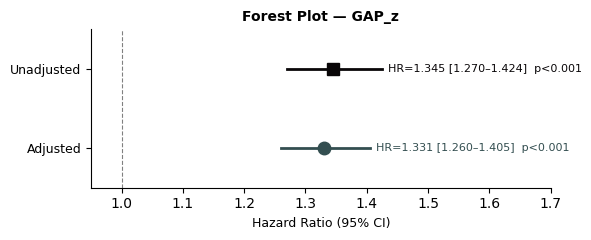

In [21]:
forest_plot_gap(cph_z_unadj, cph_z_adj,
        color_unadj="#090608",
        color_adj="#334E50",
        save_path="Figures/Model-A_forest-plot_All-subjects-OnlyHC.pdf")

#### Meta analysis urban rural

In [24]:
matched['Countries_inc'].unique()

array(['Cuba', 'DR', 'Peru (urban)', 'Venezuela', 'Mexico (rural)',
       'Puerto Rico', 'Peru (rural)', 'Mexico (urban)'], dtype=object)

In [22]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

meta_results = []

matched_for_meta = matched.copy()

matched_for_meta['Countries_inc'] = matched_for_meta['Countries_inc'].replace({
  'Peru (urban)': 'Peru',
  'Peru (rural)': 'Peru',
  'Mexico (rural)': 'Mexico',
  'Mexico (urban)': 'Mexico',
  'DR': 'Dominican R.'
})

for country in matched_for_meta['Countries_inc'].dropna().unique():
  
  c_matched = matched_for_meta[matched_for_meta['Countries_inc'] == country].copy()
  
  c_matched["Male"] = (c_matched["Sex_1F_2M"] == 2).astype(int)
  
  # Standardize within country
  sd_gap = c_matched["GAP_corrected"].std()
  
  if pd.isna(sd_gap) or sd_gap == 0:
    print(f"Skipping {country}: GAP_corrected std is 0 or NaN")
    continue
  
  c_matched["GAP_z"] = (matched["GAP_corrected"] - c_matched["GAP_corrected"].mean()) / c_matched["GAP_corrected"].std()


  # Unadjusted Cox model
  df_z_unadj = c_matched[["time_years", "event", "GAP_z"]].dropna()
  
  n = len(df_z_unadj)
  n_events = df_z_unadj["event"].sum()
  
  # Skip countries with too little information
  if n < 10 or n_events < 3:
    print(f"Skipping {country}: too few observations or events (n={n}, events={n_events})")
    continue
  
  try:
    cph_z_unadj = CoxPHFitter()
    cph_z_unadj.fit(df_z_unadj, duration_col="time_years", event_col="event")
    
    row = cph_z_unadj.summary.loc["GAP_z"]
    
    meta_results.append({
      "country": country,
      "n": n,
      "events": n_events,
      "logHR": row["coef"],
      "HR": row["exp(coef)"],
      "SE": row["se(coef)"],
      "lower_CI": row["exp(coef) lower 95%"],
      "upper_CI": row["exp(coef) upper 95%"],
      "p_value": row["p"]
    })
    
    print(f"Done: {country}")
    
  except Exception as e:
    print(f"Error in {country}: {e}")

meta_df = pd.DataFrame(meta_results)
meta_df.to_csv('MetaAnalysis/Model-A-meta-table-OnlyHC.csv')
display(meta_df)

Done: Cuba
Done: Dominican R.
Done: Peru
Done: Venezuela
Done: Mexico
Done: Puerto Rico


,country,n,events,logHR,HR,SE,lower_CI,upper_CI,p_value
0,Cuba,1719,320,0.264507,1.302789,0.051703,1.177238,1.441729,3.122711e-07
1,Dominican R.,1318,274,0.259071,1.295726,0.056373,1.160188,1.447099,4.314275e-06
2,Peru,1405,68,0.298120,1.347324,0.109308,1.087499,1.669225,6.384593e-03
3,Venezuela,1414,110,0.344815,1.411728,0.084550,1.196139,1.666175,4.538344e-05
4,Mexico,1463,86,0.334378,1.397071,0.097413,1.154251,1.690973,5.978829e-04
5,Puerto Rico,1262,139,0.339113,1.403703,0.080144,1.199656,1.642455,2.323272e-05


#### Survive curve

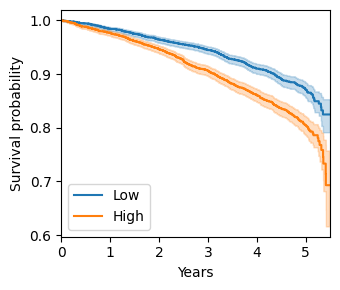

In [23]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt


matched["GAP_group"] = np.where(matched["GAP_corrected"] <= 0, "Low", "High")
matched["GAP_group_bin"] = np.where(matched["GAP_corrected"] <= 0, 0, 1)
matched["GAP_group"].value_counts(dropna=False)


kmf = KaplanMeierFitter()
plt.figure(figsize=(3.5,3.0))

for g in ["Low", "High"]:
  mask = matched["GAP_group"] == g
  df_g = matched.loc[mask, ["time_years", "event"]].dropna()
  kmf.fit(df_g["time_years"], df_g["event"], label=g)
  kmf.plot_survival_function(ci_show=True)

plt.xlabel("Years")
plt.ylabel("Survival probability")
#plt.title("Kaplan–Meier survival by GAP_corrected (≤0 vs >0)")
plt.tight_layout()
plt.xlim([0,5.5])
plt.savefig("Figures/Model-A_kaplan_meier_All-subjects-OnlyHC.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()


#### Log rank

In [24]:
from lifelines.statistics import logrank_test

df_low = matched.loc[matched["GAP_group"]=="Low", ["time_years","event"]].dropna()
df_high = matched.loc[matched["GAP_group"]=="High", ["time_years","event"]].dropna()

lr = logrank_test(
  df_low["time_years"], df_high["time_years"],
  event_observed_A=df_low["event"],
  event_observed_B=df_high["event"]
)

print(f"Log-rank p = {lr.p_value:.3g}")


Log-rank p = 2.36e-14


In [ ]:
df_low = matched.loc[matched["GAP_group"]=="Low", "event"].dropna()

# P0 = proportion of events in the reference group (Low)
p0 = df_low.sum() / len(df_low)
print(f"P0 = {p0:.3f}")

P0 = 0.089
